In [141]:
import xarray as xr 
import matplotlib.pyplot as plt 
import numpy as np
import mpltern 
import numpy as np 
import xarray as xr 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from scipy.stats import entropy 
from sklearn.neighbors import KNeighborsClassifier 

In [155]:
data_dir = "/Users/knv2/Documents/codebase/labeler_sweeps/phase_data"

In [156]:
def barycentric_to_cartesian(compositions):
    """
    Convert 3-component barycentric coordinates (a, b, c) with sum=1
    into 2D Cartesian coordinates for ternary plotting.

    Parameters
    ----------
    compositions : array-like, shape (n_samples, 3)
        Each row is (a, b, c), where a+b+c=1.

    Returns
    -------
    coords : ndarray, shape (n_samples, 2)
        Cartesian coordinates (x, y).
    """
    comps = np.asarray(compositions)
    if comps.shape[1] != 3:
        raise ValueError("Input must have shape (n_samples, 3).")

    a, b, c = comps[:, 0], comps[:, 1], comps[:, 2]
    x = 0.5 * (2 * b + c)
    y = (np.sqrt(3) / 2) * c

    return np.column_stack([x, y])

In [180]:
ds = xr.load_dataset(data_dir+"/pm-0.0-1275.nc")
# pick distinct colors for each label
labels = ds.labels.values
unique_labels = np.unique(ds.labels.values)
cmap = plt.get_cmap("tab10", len(unique_labels))
label_to_color = {lab: cmap(i) for i, lab in enumerate(unique_labels)}
le = LabelEncoder()
le.fit(labels)
grid = ds.compositions.values
grid_barycentric = barycentric_to_cartesian(grid)

In [181]:
def plot_ternary_phasemap(domain, labels,ax = None):
    colors = [label_to_color[l] for l in labels]

    # plot ternary diagram
    if ax is None:
        fig = plt.figure(figsize=(7, 6))
        ax = fig.add_subplot(111, projection="ternary")
    else:
        fig = plt.gcf()

    # Ternary expects columns (left, right, bottom)
    ax.scatter(
        domain[:, 0],  # left
        domain[:, 1],  # right
        domain[:, 2],  # bottom
        c=colors,
        s=25
    )

    # legend for labels
    for lab in unique_labels:
        ax.scatter([], [], [],  c=[label_to_color[lab]], label=lab, s=30)
    ax.legend(title="Labels", bbox_to_anchor=(1.05, 1), loc="upper left")

    ax.set_tlabel("Component 1")
    ax.set_llabel("Component 2")
    ax.set_rlabel("Component 3")

    if ax is None:
        plt.tight_layout()
        plt.show()

def plot_ternary_function(domain, codomain, ax = None):
    if ax is None:
        fig = plt.figure(figsize=(7, 6))
        ax = fig.add_subplot(111, projection="ternary")
    else:
        fig = plt.gcf()
    # Ternary expects columns (left, right, bottom)
    sc = ax.tricontourf(
        domain[:, 0],  # left
        domain[:, 1],  # right
        domain[:, 2],  # bottom
        codomain,
        cmap="magma",
        alpha = 1.0
    )
    cax = ax.inset_axes([1.05, 0.1, 0.05, 0.9], transform=ax.transAxes)
    cbar = fig.colorbar(sc, cax=cax)

    ax.set_tlabel("Component 1")
    ax.set_llabel("Component 2")
    ax.set_rlabel("Component 3")

    if ax is None:
        plt.tight_layout()
        plt.show()
        
        return fig, ax, cbar
    else:
        return cbar 

def plot_ternary_levelset(domain, codomain, vmin, vmax, ax = None):
    if ax is None:
        fig = plt.figure(figsize=(7, 6))
        ax = fig.add_subplot(111, projection="ternary")
    else:
        fig = plt.gcf()

    masked_codomain = np.where((codomain >= vmin) & (codomain <= vmax), 1.0, -1.0)
    ax.tricontour(
        domain[:, 0],  # left
        domain[:, 1],  # right
        domain[:, 2],  # bottom
        masked_codomain,
        levels = [0.0],
        colors='w', 
        linewidths=2
    )
    
    ax.set_tlabel("Component 1")
    ax.set_llabel("Component 2")
    ax.set_rlabel("Component 3")

    if ax is None:
        plt.tight_layout()
        plt.show()
        
        return fig, ax
    else:
        return 

def plot_ternary_phase_boundary(domain, labels, ax = None):
    if ax is None:
        fig = plt.figure(figsize=(7, 6))
        ax = fig.add_subplot(111, projection="ternary")
    else:
        fig = plt.gcf()

    for phase in np.unique(labels):
        masked_codomain = np.where(labels==phase, 1.0, -1.0)
        ax.tricontour(
            domain[:, 0],  # left
            domain[:, 1],  # right
            domain[:, 2],  # bottom
            masked_codomain,
            levels = [0.0],
            colors='k', 
            linewidths=2
        )
    
    ax.set_tlabel("Component 1")
    ax.set_llabel("Component 2")
    ax.set_rlabel("Component 3")

    if ax is None:
        plt.tight_layout()
        plt.show()
        
        return fig, ax
    else:
        return 

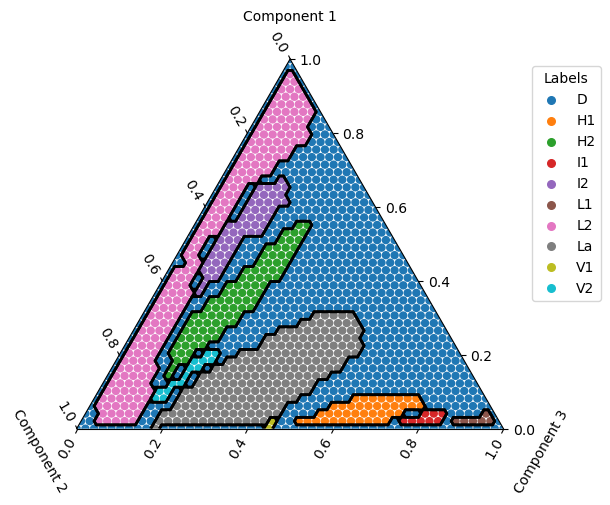

In [182]:
fig, ax = plt.subplots(subplot_kw={"projection":"ternary"})
plot_ternary_phasemap(ds["compositions"].values, ds["labels"].values, ax = ax)
plot_ternary_phase_boundary(ds["compositions"].values, ds["labels"].values, ax = ax)

In [185]:
def extract_boundaries_mpltern(domain, labels):
    """
    Extract boundary contour lines (in barycentric coordinates) for each phase
    label from a discrete ternary phase map. Uses Matplotlib's tricontour
    internally without displaying plots.

    Parameters
    ----------
    domain : (N, 3) ndarray
        Array of barycentric coordinates (t, l, r) of sampling points.
        Each row must satisfy t + l + r = 1.
    labels : (N,) ndarray
        Array of integer labels assigning a phase to each domain point.

    Returns
    -------
    boundaries : dict
        Dictionary mapping each unique phase label to a list of arrays.
        Each array has shape (M, 3) and contains the barycentric (t, l, r)
        coordinates of a contour segment (boundary) for that phase.

    Notes
    -----
    - Each phase may have multiple disconnected boundary segments, so the
      return value for a label is a list of arrays.
    - Contours are extracted at level 0 from a binary mask where the phase
      is assigned +1 and all others -1.
    - This function creates temporary Matplotlib figures internally but
      closes them immediately to avoid displaying plots.
    """
    boundaries = {}
    for phase in np.unique(labels):
        masked_codomain = np.where(labels == phase, 1.0, -1.0)

        fig, axs = plt.subplots(
            1,2, 
            figsize=(4*2, 4), 
            subplot_kw={"projection":"ternary"}
        )
        ax = axs[0]
        ax.scatter(
            domain[:,0], 
            domain[:,1], 
            domain[:,2],
            s = 5,
            color="k"
        )
        cs = ax.tricontour(
            domain[:,0], 
            domain[:,1], 
            domain[:,2],
            masked_codomain, 
            levels=[0.0],
            color = "w"
        )
        vertices = []
        for polygon in cs.allsegs[0]: # should be only single level at 0.0
            for vertex in polygon:
                coords = ax.transProjection.inverted().transform(vertex)
                vertices.append(coords)
        boundaries[str(phase)] = np.asarray(vertices).squeeze()

        ax = axs[1]
        ax.scatter(
            boundaries[str(phase)][:,0], 
            boundaries[str(phase)][:,1], 
            boundaries[str(phase)][:,2],
            s=10,
            label = phase
        )

        plt.close(fig)  # avoid showing the figure

    return boundaries

boundaries = extract_boundaries_mpltern(ds["compositions"].values, ds["labels"].values)

In [149]:
X = barycentric_to_cartesian(ds["compositions"].values)
y = le.transform(ds["labels"].values)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42, stratify=y) 

X_train = X_train.astype('float32')
X_test = X_test.astype('float32')
y_train = y_train.astype('int64')
y_test = y_test.astype('int64')

clf = KNeighborsClassifier(n_neighbors=5)
clf.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


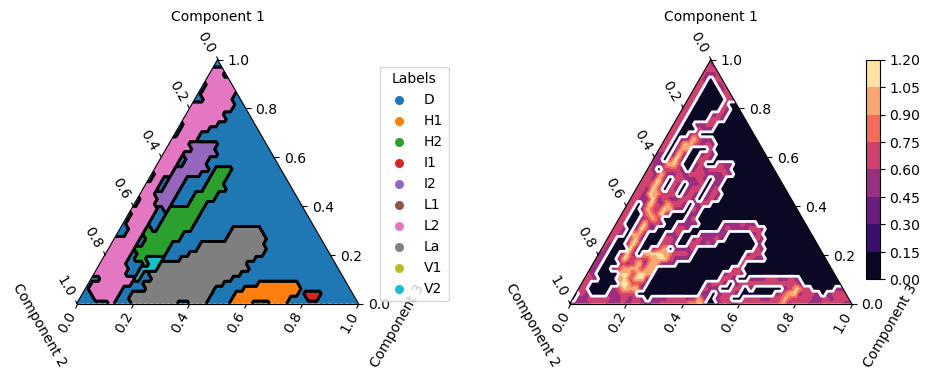

In [150]:
pred_labels = le.inverse_transform(clf.predict(grid_barycentric))
probs = clf.predict_proba(grid_barycentric)
scores = entropy(probs, axis=1)
fig, axs = plt.subplots(
    1,2, 
    figsize=(5*2, 5), 
    subplot_kw={"projection":"ternary"}
)
fig.subplots_adjust(wspace=0.75)
plot_ternary_phasemap(grid, pred_labels, ax = axs[0])
plot_ternary_phase_boundary(grid, pred_labels, ax = axs[0])

plot_ternary_function(grid, scores, ax = axs[1])
plot_ternary_levelset(grid, scores, 0.0, 0.3, ax = axs[1])
plt.show()

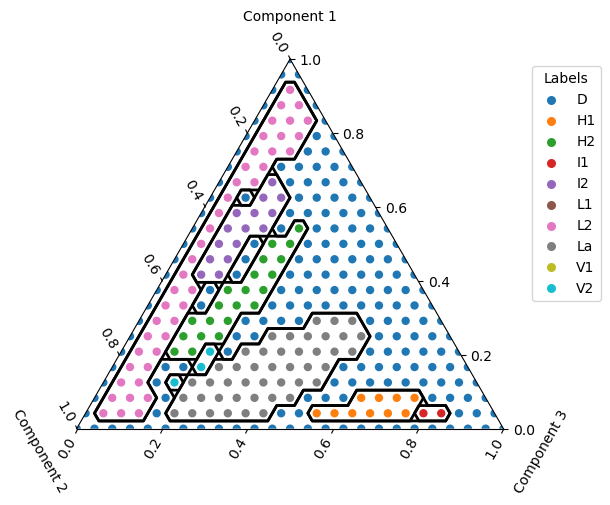

In [151]:
ds = xr.load_dataset(data_dir+"/pm-0.0-325.nc")
fig, ax = plt.subplots(subplot_kw={"projection":"ternary"})
plot_ternary_phasemap(ds["compositions"].values, ds["labels"].values, ax = ax)
plot_ternary_phase_boundary(ds["compositions"].values, ds["labels"].values, ax = ax)
plt.show()

In [152]:
X = barycentric_to_cartesian(ds["compositions"].values)
y = le.transform(ds["labels"].values)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42, stratify=y) 

X_train = X_train.astype('float32')
X_test = X_test.astype('float32')
y_train = y_train.astype('int64')
y_test = y_test.astype('int64')

clf = KNeighborsClassifier(n_neighbors=5)
clf.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


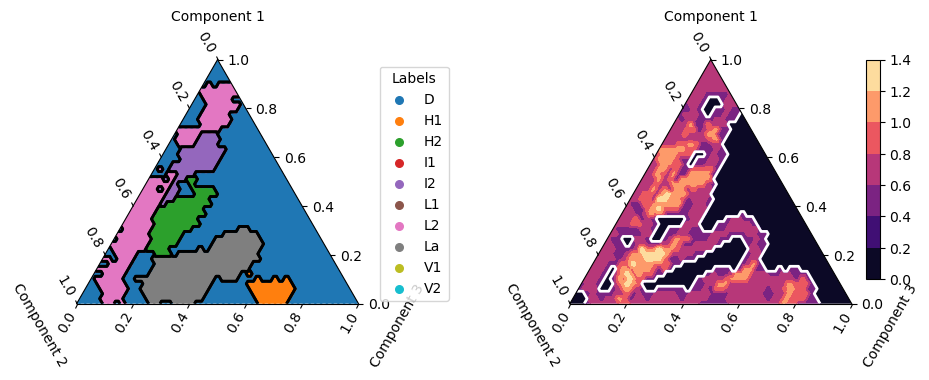

In [153]:
pred_labels = le.inverse_transform(clf.predict(grid_barycentric))
probs = clf.predict_proba(grid_barycentric)
scores = entropy(probs, axis=1)
fig, axs = plt.subplots(
    1,2, 
    figsize=(5*2, 5), 
    subplot_kw={"projection":"ternary"}
)
fig.subplots_adjust(wspace=0.75)
plot_ternary_phasemap(grid, pred_labels, ax = axs[0])
plot_ternary_phase_boundary(grid, pred_labels, ax = axs[0])
plot_ternary_function(grid, scores, ax = axs[1])
plot_ternary_levelset(grid, scores, 0.0, 0.2, ax = axs[1])
plt.show()

## Fitting GP Model 

from typing import List, Self
import numpy as np
import xarray as xr
from AFL.double_agent.Generator import Generator 
from AFL.double_agent.PyTorchExtrapolator import DirichletGPExtrapolator
from AFL.double_agent.Generator import BarycentricGrid
from AFL.double_agent.Pipeline import Pipeline 

class BarycentricTo2D(Generator):
    """Generator that converts barycentric coordinates (3D) to 2D Cartesian coordinates.

    This generator maps points in 3D compositional (barycentric) space, where
    the sum of the three components equals a fixed basis (typically 1.0),
    into 2D coordinates suitable for plotting in a ternary diagram.

    Parameters
    ----------
    input_variable : str
        Name of the variable in the dataset containing barycentric compositions
        (shape: [sample, 3]).

    output_variable : str
        Name of the variable to store the resulting 2D coordinates.

    sample_dim : str
        Dimension name for the samples/points.

    basis : float, default=1.0
        Normalization factor for the compositions (sum of components).

    name : str, default="BarycentricTo2D"
        Name to use when added to a pipeline.
    """

    def __init__(
        self,
        input_variable: str,
        output_variable: str,
        sample_dim: str,
        basis: float = 1.0,
        name: str = "BarycentricTo2D",
    ):
        super().__init__(
            name=name, input_variable=input_variable, output_variable=output_variable
        )
        self.sample_dim = sample_dim
        self.basis = basis

    def calculate(self, dataset: xr.Dataset) -> Self:
        """Convert barycentric coordinates to 2D.

        Parameters
        ----------
        dataset : xr.Dataset
            Dataset containing barycentric compositions in `input_variable`.

        Returns
        -------
        Self
            Generator instance with the converted 2D coordinates.
        """
        bary = dataset[self.input_variable].values  # shape: [sample, 3]

        # normalize if needed
        bary = bary / self.basis

        a = bary[:, 0]
        b = bary[:, 1]
        c = bary[:, 2]

        # Standard ternary -> 2D mapping:
        # x = 0.5 * (2*b + c) / (a+b+c)
        # y = (np.sqrt(3)/2) * c / (a+b+c)
        x = 0.5 * (2 * b + c) / (a + b + c)
        y = (np.sqrt(3) / 2) * c / (a + b + c)

        coords_2d = np.stack([x, y], axis=1)

        # Add result to output
        self.output[self.output_variable] = xr.DataArray(
            coords_2d,
            dims=[self.sample_dim, "xy"],
            coords={"xy": ["x", "y"]},
        )

        return self

gp_params_mcmc = {"num_samples":25, "num_warmup":25, "method":"mcmc", "verbose":True} 

with Pipeline() as p:
    BarycentricGrid(
        output_variable='composition_grid',
        components = ['a','b','c'],
        sample_dim='grid',
    )
    BarycentricTo2D(
        input_variable="compositions",
        output_variable="compositions_ternary",
        sample_dim="sample",
        name="BarycentricTo2D-Compositions"
    )
    BarycentricTo2D(
        input_variable="composition_grid",
        output_variable="compositions_grid_ternary",
        sample_dim="grid",
        name="BarycentricTo2D-Grid"
    )    
    DirichletGPExtrapolator(
        feature_input_variable="compositions_ternary",
        predictor_input_variable="label_numeric",
        output_prefix="gp",
        grid_variable="compositions_grid_ternary",
        grid_dim="grid",
        sample_dim="sample",
        component_dim = "xy",
        params=gp_params_mcmc,
        name="GP",
    )
p.print()
ds_result = p.calculate(ds)